## feature engineering 

In [47]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
import numpy as np 

In [48]:
NOTEBOOK_DIR=Path.cwd()
ROOT_DIR=NOTEBOOK_DIR.parent
DIR_DATA=ROOT_DIR/"data"
DIR_DATA_RAW=DIR_DATA/"raw"
DIR_DATA_PROCESSED=DIR_DATA/"processed"
DIR_DATA

PosixPath('/Users/essalehachraf/Market-Neutral-Alpha-Prediction/data')

In [49]:
X_train_processed=pd.read_csv(DIR_DATA_PROCESSED/"x_train_processed.csv",index_col="ID")
display(X_train_processed)
#print(f"{int(X_train_processed['SECTOR'].min()) , int(X_train_processed['SECTOR'].max())}")

Y_train=pd.read_csv(DIR_DATA_RAW/"y_train.csv",index_col="ID")
print(f" y_traine has {Y_train.size} rows")

,DATE,STOCK,INDUSTRY,INDUSTRY_GROUP,SECTOR,SUB_INDUSTRY,RET_1,VOLUME_1,RET_2,VOLUME_2,...,RET_16_missing,VOLUME_16_missing,RET_17_missing,VOLUME_17_missing,RET_18_missing,VOLUME_18_missing,RET_19_missing,VOLUME_19_missing,RET_20_missing,VOLUME_20_missing
ID,,,,,,,,,,,,,,,,,,,,,
0,0,2,18,5,3,44,-0.015748,0.147931,-0.015504,0.179183,...,0,0,0,0,0,0,0,0,0,0
1,0,3,43,15,6,104,0.003984,-0.333778,-0.090580,-0.332121,...,0,1,0,1,0,1,0,1,0,1
2,0,4,57,20,8,142,0.000440,-0.096282,-0.058896,0.084771,...,0,0,0,0,0,0,0,0,0,0
3,0,8,1,1,1,2,0.031298,-0.429540,0.007756,-0.089919,...,0,0,0,0,0,0,0,0,0,0
4,0,14,36,12,5,92,0.027273,-0.847155,-0.039302,-0.943033,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418590,223,5703,32,10,4,77,0.021843,-0.217823,-0.021703,-0.125333,...,0,0,0,0,0,0,0,0,0,0
418591,223,5705,35,12,5,91,-0.006920,-0.375251,0.000000,-0.029437,...,0,0,0,0,0,0,0,0,0,0
418592,223,5709,2,1,1,5,0.021869,-0.978856,-0.005929,-1.026267,...,0,0,0,0,0,0,0,0,0,0


 y_traine has 418595 rows


In [50]:
X_train_processed["DATE"].describe()

count    418595.000000
mean        108.659002
std          61.891642
min           0.000000
25%          56.000000
50%         104.000000
75%         161.000000
max         223.000000
Name: DATE, dtype: float64

## Starting point feature engineering:

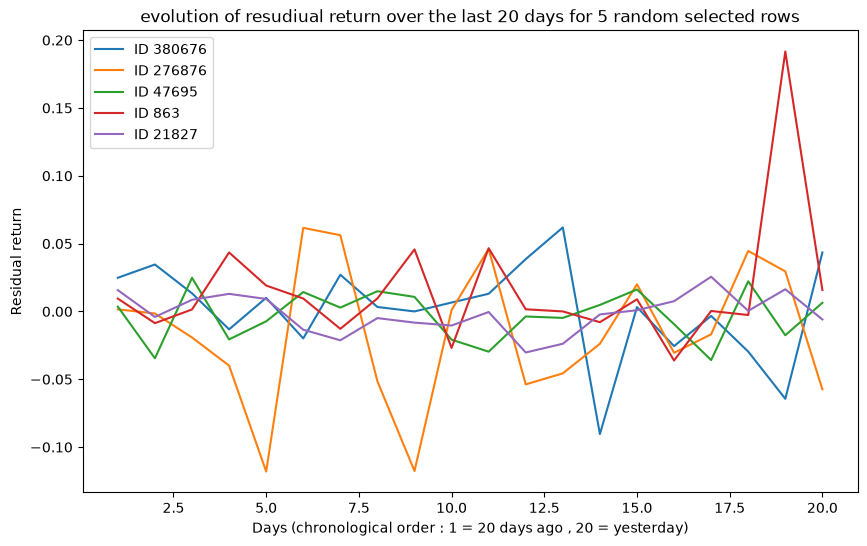

In [51]:
ret_i=[f"RET_{i}" for i in range(20,0,-1)]
df_ret20_ret1=X_train_processed[ret_i]

sample_rows=df_ret20_ret1.sample(n=5,random_state=42)

plt.figure(figsize=(10,6))
for idx, row in sample_rows.iterrows():
    y=row[ret_i].values 
    x=range(1,21)
    plt.plot(x,y,label=f"ID {idx}")
plt.xlabel("Days (chronological order : 1 = 20 days ago , 20 = yesterday)")
plt.ylabel("Residual return")
plt.title("evolution of resudiual return over the last 20 days for 5 random selected rows")
plt.legend()

- We can see that there's no particular pattern between the 5 stocks (no shared spike or dip at the same time), this tells us that residual returns are stock specific **which is what residual is supposed to look like** no market effect 

- most residual returns set in a tha band of +- 0.05 with occasional large spikes 

- **this confirms that compressing noise into more informative features is mandatory**, we re going to use agregate statistics(volatility, momentum etc)

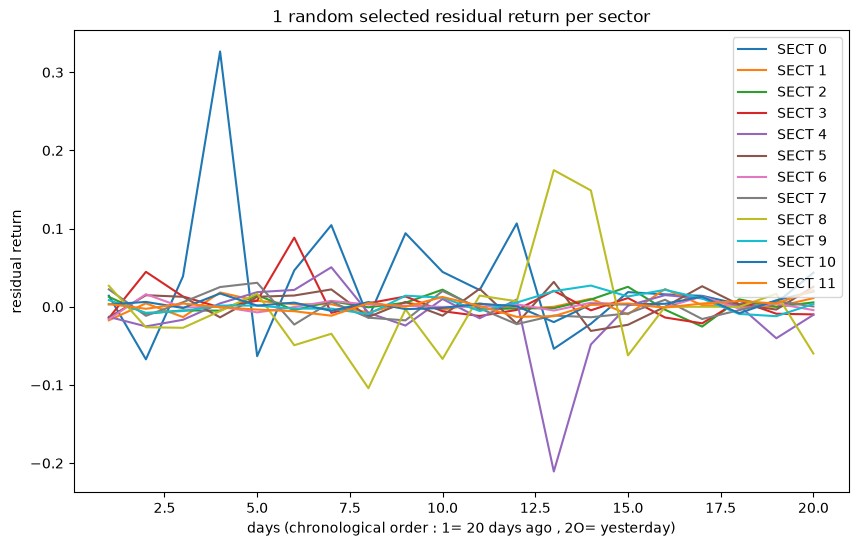

In [52]:
ret_i_sector= pd.concat([df_ret20_ret1, X_train_processed["SECTOR"]], axis=1) 
sectors=ret_i_sector["SECTOR"].unique()
row_sample_by_sector= ret_i_sector.groupby("SECTOR").sample(n=1, random_state=42)

plt.figure(figsize=(10,6))
for idx, row in row_sample_by_sector.iterrows():
    y=row[ret_i].values
    x=range(1,21)
    plt.plot(x,y,label=f"SECT {int(row['SECTOR'])}")
    
plt.xlabel("days (chronological order : 1= 20 days ago , 2O= yesterday)")
plt.ylabel("residual return")
plt.title("1 random selected residual return per sector")
plt.legend()


- sector (alone) doesn't creat a visually distinguishable shape in the return path 
- if it does it can be with some agregate statistics

**since the signal is very week here, in order to not spend hours in FE and realise that features we creat are just noise... we're going to follow a loop : creature a feature -> evaluating corrrelation/relationship with the target --> keep or discard? --> move on to the next**

Backtracking : found a features distribution suspicious 

In [53]:
ret_20=[f"RET_{i}" for i in range(1,21)]
ret_5=[f"RET_{i}" for i in range(1,6)]
(X_train_processed[ret_20].abs()>5).sum()

RET_1     0
RET_2     0
RET_3     0
RET_4     0
RET_5     0
RET_6     0
RET_7     0
RET_8     0
RET_9     0
RET_10    0
RET_11    0
RET_12    1
RET_13    0
RET_14    0
RET_15    0
RET_16    0
RET_17    0
RET_18    1
RET_19    0
RET_20    1
dtype: int64

In [54]:
outlier_rows=X_train_processed[X_train_processed[ret_20].abs().gt(5).any(axis=1)]
outlier_rows[ret_20].T

ID,117974,128997,348132
RET_1,-0.012500,-0.074830,-0.002736
RET_2,-0.020408,0.195122,-0.002975
RET_3,0.020833,-0.151724,0.005736
RET_4,0.116279,0.306307,-0.014257
RET_5,0.023810,-0.354651,-0.001228
RET_6,-0.009435,-0.028249,0.000491
RET_7,0.029126,-0.073299,0.008173
RET_8,0.030000,0.273333,0.005228
RET_9,0.000000,0.376149,0.009043
RET_10,-0.103541,-0.148438,0.007593


- after scanning all ret1,...ret20 columns to detect values >5 (500% of single day RESIDUAL return), we have found 3 suspicious values around nearly 400k rows : 
    - id = 117974 with a value of 118.999563 in RET_12 
    - id= 128997 with a value of 6.000004 (600%)
    - id = 348132 with a value of 7.208859 (720%)
- those 3 rows show a extreme value around more calm plausible values, since 3/400K+ is a tiny percentage we gonna use a clip/cap to floor -1 , 1 cap, in order to not influence our statisitics ( that are sensitice the outliers like mean and the std ) 

In [55]:
X_train_processed[ret_20]=X_train_processed[ret_20].clip(-1,1)
#(X_train_processed[ret_20].abs()>5).sum()

## 1.a Short term volatility : std of ret_1... ret_5

In [56]:
ret_1_5=[f"RET_{i}" for i in range(1,6)]
df_ret20_ret1["RET_STD_5"]=df_ret20_ret1[ret_1_5].std(axis=1)
df_ret20_ret1

,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,RET_12,RET_11,...,RET_9,RET_8,RET_7,RET_6,RET_5,RET_4,RET_3,RET_2,RET_1,RET_STD_5
ID,,,,,,,,,,,,,,,,,,,,,
0,-0.002155,-0.012959,0.008752,0.003254,0.059459,-0.028571,-0.049370,0.027624,0.030108,0.013570,...,0.134146,-0.018433,-0.017215,0.014331,0.016483,-0.014672,0.010972,-0.015504,-0.015748,0.016027
1,-0.034722,-0.028777,-0.018518,0.003774,0.015413,-0.004073,-0.052044,-0.019608,-0.028000,-0.008230,...,0.158731,0.023973,-0.026756,-0.006873,-0.038062,-0.025540,0.018826,-0.090580,0.003984,0.042498
2,-0.006867,-0.012101,-0.006562,-0.017612,0.008964,-0.007552,-0.002686,-0.009426,0.028093,-0.012781,...,-0.006342,-0.002979,-0.023047,0.027522,0.009354,0.024852,-0.009042,-0.058896,0.000440,0.031757
3,-0.036745,-0.013520,-0.001468,0.033824,-0.031769,0.021057,0.000479,-0.010067,0.007264,0.007693,...,0.014146,-0.004329,-0.043962,-0.002021,0.003544,-0.019677,-0.004632,0.007756,0.031298,0.018668
4,-0.040817,0.004256,0.004237,-0.012659,-0.038461,-0.026667,0.095891,-0.041667,-0.004348,-0.008734,...,-0.008621,-0.017391,-0.026549,0.018182,0.022321,0.000000,0.000000,-0.039302,0.027273,0.026294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418590,0.031174,-0.058448,0.008205,0.007785,0.003160,-0.001750,-0.017532,-0.004996,0.019369,-0.003519,...,0.020077,-0.008287,-0.020195,0.028785,0.001727,0.021379,0.011141,-0.021703,0.021843,0.017999
418591,-0.011073,-0.015396,0.007819,-0.016221,0.007169,-0.000711,-0.004986,-0.001432,-0.003584,0.000000,...,0.007863,0.000000,-0.013476,0.012941,0.009226,0.009143,0.006968,0.000000,-0.006920,0.007023
418592,0.098607,-0.082927,-0.069148,0.029714,0.001110,0.013304,0.024070,-0.001068,0.047058,0.032687,...,0.001890,0.024928,-0.011628,-0.008824,-0.015826,0.006030,0.010989,-0.005929,0.021869,0.014682


- let's check the correlation with the target... since our target is binary (the signe of tomorrow's residual return), we're doing a special case of pearson correlation called point biserial correlation 

In [57]:
# since the target is on another csv we will have to creat a new df with the 2 variables
df_target_std_ret5=pd.concat(
    [df_ret20_ret1["RET_STD_5"],Y_train["RET"]],
    axis=1
    )
df_target_std_ret5


,RET_STD_5,RET
ID,,
0,0.016027,True
1,0.042498,True
2,0.031757,False
3,0.018668,False
4,0.026294,False
...,...,...
418590,0.017999,False
418591,0.007023,False
418592,0.014682,True


## point biserial correlation

In [58]:
corr=df_target_std_ret5['RET_STD_5'].corr(df_target_std_ret5['RET'])
float(corr)

-0.011872638688746114

- almost non llineaire relationship

- We have a negative correlation, a week negative lineaire relationship between the short term volatility and the binary target... let's compare the distribution of target=TRUE and target=FALSE
- even small negative correaltion can hide differences between two classes :)
meaning we're answering does volatility look different when tomorrow's residual looks potive or negative ?

In [59]:
df_target_std_ret5.groupby("RET")["RET_STD_5"].agg(["count","mean","median","std"])

,count,mean,median,std
RET,,,,
False,209749,0.023217,0.017633,0.021381
True,208846,0.022700,0.016905,0.022110


- We can see that the statisitics of both classes are slightly the same, that's evidence that short term volatility doesn't separe the classes...

Text(0.5, 0.98, '')

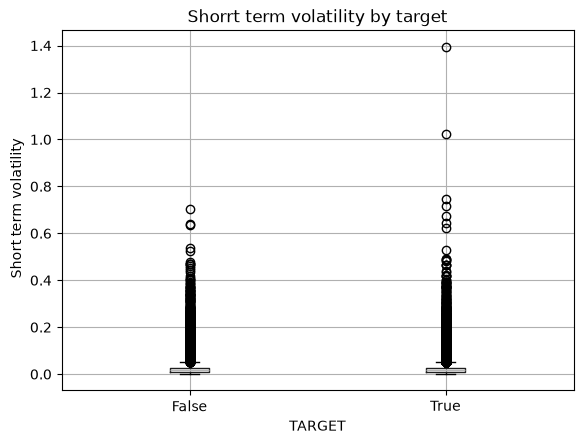

In [60]:
df_target_std_ret5.boxplot(
    column="RET_STD_5",
    by="RET"
)
plt.xlabel("TARGET")
plt.ylabel(" Short term volatility")
plt.title("Shorrt term volatility by target")
plt.suptitle("")
#plt.ylim(0,0.04)

- the boxplot shows that the distribution of the classes is slightly identical positive return has several outliers with the most extreme (at y=1.4 and 1.0 ), we can conclude that the short term voalitility doesn't separate classes ... it shows non lineair relationship with the target but we will keept it because ***tree bases models can capture non lineaire relationships or interaction effects with other feature***, so we will let feature importance decide ...

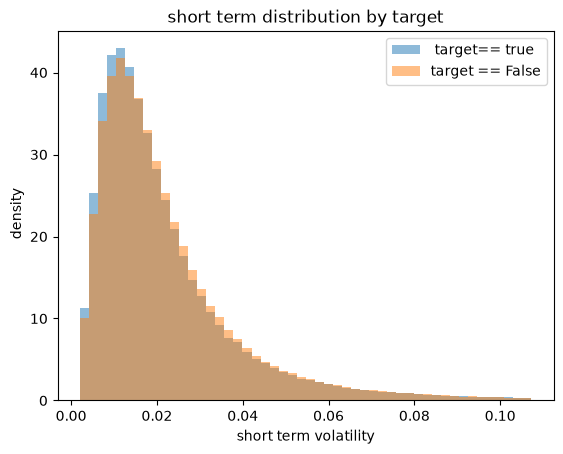

In [61]:
lower,upper = df_target_std_ret5["RET_STD_5"].quantile([0.01,0.99])
plt.hist(
    df_target_std_ret5[df_target_std_ret5["RET"]==True]["RET_STD_5"],
    bins=50,
    alpha=0.5,
    label=" target== true",
    range=(lower,upper),
    density="True",
    #histtype="step"
)
plt.hist(
    df_target_std_ret5[df_target_std_ret5["RET"]==False]["RET_STD_5"],
    bins=50,
    alpha=0.5,
    label="target == False",
    range=(lower,upper),
    density=True,
   # histtype="step"
)

plt.xlabel("short term volatility")
plt.ylabel(" density")
plt.title("short term distribution by target")
#plt.xlim(0,0.1)
plt.legend()

- distribution density histogram show overllaping almost perfectly between classes i.e not shape diffences neither
- both are right skewed with a peak at nearly 0.01

- let's do the same analysis on longterm volatility

# 1.b long term vol :  std across its ret1,..., ret 20 

In [79]:
df_ret20_ret1["RET_STD_20"]=df_ret20_ret1.std(axis=1)
#df_ret20_ret1



In [80]:
df_target_std_ret20= pd.concat(
    [df_ret20_ret1["RET_STD_20"],Y_train["RET"]],
    axis=1
)
#df_target_std_ret20

In [81]:
corr_long_vol_target=df_target_std_ret20["RET"].corr(df_target_std_ret20["RET_STD_20"])
float(corr_long_vol_target)

-0.007120902454429076

- almost non linear relation ship between long term volatility and the target... ( low negative relationship )
- correlation between the short term volatility and the target is higher that the long term volatility with the target... which is normal recent fluctuation of the market give more information on next move than old fluctuation...
- let's see if tomorrow's volatility looks different when tomorrow's return is positive or negative ...

In [82]:
df_target_std_ret20.groupby(df_target_std_ret20['RET'])['RET_STD_20'].aggregate(["count","mean","median","std"])

,count,mean,median,std
RET,,,,
False,209749,0.024390,0.019803,0.018401
True,208846,0.023791,0.019109,0.056652


- first three statistics are almost the same regardless of target output ... 
- we can see that standard deviation is higher when the return is positive rather than when it's negative ... meaning the spread of the variation around the mean is higher when the return is positive 
- we need to visualise the distribution of the target and the new feature 

(0.004489974495461855, 0.09211870522877082)

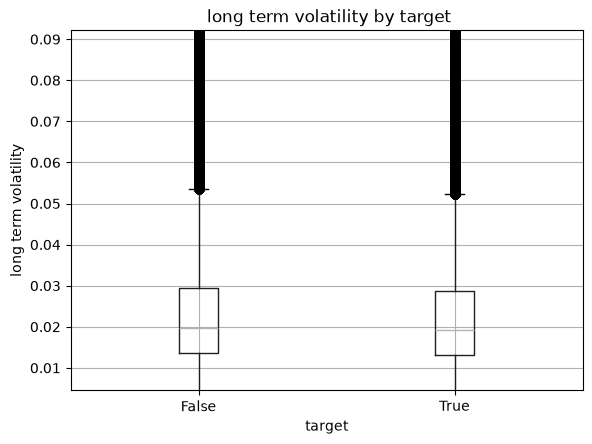

In [85]:
lower,upper=df_target_std_ret20["RET_STD_20"].quantile([0.01, 0.99])
df_target_std_ret20.boxplot(
    column='RET_STD_20',
    by='RET'
    
)
plt.xlabel ("target")
plt.ylabel(" long term volatility ")
plt.title(" long term volatility by target")
plt.suptitle("")
plt.ylim(lower,upper)

- as before the distribution of the classes are nearly symetrical ( as statstics confirmed it ), we have outliers in two classes with extrem outliers on both sides (higher on True class 0.72 vs 0.64 in the left class) ... we can conclude that thre's no lineaire relationship between the target and long term volatility... 
- despite that fact we're not gonna drop the feature because based tree models are capable to capture non linearity or features interactions... 
- We re going to let feature importance do the job

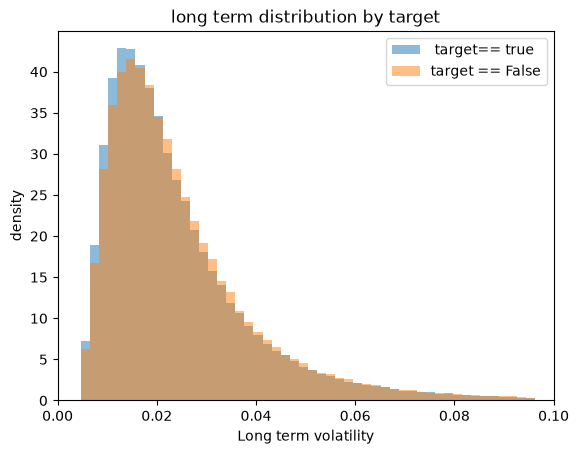

In [67]:
lower,upper= df_target_std_ret20["RET_STD_20"].quantile([0.01,0.99])
plt.hist(
    df_target_std_ret20[df_target_std_ret20["RET"]==True]["RET_STD_20"],
    bins=50,
    alpha=0.5,
    label=" target== true",
    range=(lower,upper),
    density="True",
    #histtype="step"
)
plt.hist(
    df_target_std_ret20[df_target_std_ret20["RET"]==False]["RET_STD_20"],
    bins=50,
    alpha=0.5,
    label="target == False",
    range=(lower,upper),
    density=True,
   # histtype="step"
)

plt.xlabel("Long term volatility")
plt.ylabel(" density ")
plt.title("long term distribution by target")
plt.xlim(0,0.1)
plt.legend()

- both distributions are right skewed with the same shape
- both peaks at nearly 0.015 
- two crves overlapp almost evrywhere ... 

- no meaningful lineair distribution signal from long term volatiity as a standalone feature 
- as we said we gonna keep it since tree based models capture non lineaire relationships and we let feature importance decide ...

## 2. momentum: is the RECENT trend up or down overall

- as a first pass we 're going to use use the mean (what's the net effect including large movements) , then the median (in order to answer what's a typical day looks like) , of RET1,..,RET20 then RET1,..,RET5 
- then we gonna give exponential weights in order to give more importance to recent day's since they capture more information about the future then old day's do 


In [68]:
ret_20=[f"RET_{i}" for i in range(1,21)]
ret_5=[f"RET_{i}" for i in range(1,6)]
df_ret20_ret1["RET_mean_20"]= df_ret20_ret1[ret_20].mean(axis=1)
df_ret20_ret1["RET_mean_5"]= df_ret20_ret1[ret_5].mean(axis=1)
df_ret20_ret1


,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,RET_12,RET_11,...,RET_6,RET_5,RET_4,RET_3,RET_2,RET_1,RET_STD_5,RET_STD_20,RET_mean_20,RET_mean_5
ID,,,,,,,,,,,,,,,,,,,,,
0,-0.002155,-0.012959,0.008752,0.003254,0.059459,-0.028571,-0.049370,0.027624,0.030108,0.013570,...,0.014331,0.016483,-0.014672,0.010972,-0.015504,-0.015748,0.016027,0.053263,0.016318,-0.003694
1,-0.034722,-0.028777,-0.018518,0.003774,0.015413,-0.004073,-0.052044,-0.019608,-0.028000,-0.008230,...,-0.006873,-0.038062,-0.025540,0.018826,-0.090580,0.003984,0.042498,0.048715,-0.005572,-0.026274
2,-0.006867,-0.012101,-0.006562,-0.017612,0.008964,-0.007552,-0.002686,-0.009426,0.028093,-0.012781,...,0.027522,0.009354,0.024852,-0.009042,-0.058896,0.000440,0.031757,0.023920,-0.001043,-0.006658
3,-0.036745,-0.013520,-0.001468,0.033824,-0.031769,0.021057,0.000479,-0.010067,0.007264,0.007693,...,-0.002021,0.003544,-0.019677,-0.004632,0.007756,0.031298,0.018668,0.020854,-0.003154,0.003658
4,-0.040817,0.004256,0.004237,-0.012659,-0.038461,-0.026667,0.095891,-0.041667,-0.004348,-0.008734,...,0.018182,0.022321,0.000000,0.000000,-0.039302,0.027273,0.026294,0.031905,-0.003551,0.002059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418590,0.031174,-0.058448,0.008205,0.007785,0.003160,-0.001750,-0.017532,-0.004996,0.019369,-0.003519,...,0.028785,0.001727,0.021379,0.011141,-0.021703,0.021843,0.017999,0.020803,0.002034,0.006877
418591,-0.011073,-0.015396,0.007819,-0.016221,0.007169,-0.000711,-0.004986,-0.001432,-0.003584,0.000000,...,0.012941,0.009226,0.009143,0.006968,0.000000,-0.006920,0.007023,0.008783,-0.000310,0.003683
418592,0.098607,-0.082927,-0.069148,0.029714,0.001110,0.013304,0.024070,-0.001068,0.047058,0.032687,...,-0.008824,-0.015826,0.006030,0.010989,-0.005929,0.021869,0.014682,0.037124,0.005549,0.003427


# - long term momentum

In [86]:
df_target_mean20=pd.concat(
    [df_ret20_ret1["RET_mean_20"],Y_train["RET"]],
    axis=1
)
#df_target_mean20
corr_mean20_target= df_target_mean20["RET_mean_20"].corr(df_target_mean20["RET"])
float(corr_mean20_target)


-0.0086625614863653

- we have a week negative lineaire relationship between the long term momentum and the the target.... (almost no correlation), but since tree based models are capble to capture the nonlineaire patterns, and we're using a point biserial correaltion we need to see the behaviour of this feature on each class 

In [70]:
stat_deltas=df_target_mean20.groupby(df_target_mean20["RET"])["RET_mean_20"].aggregate(["count","mean","median","std"])
stat_deltas.loc["delta"]=np.abs(stat_deltas.loc[True]- stat_deltas.loc[False])
stat_deltas

,count,mean,median,std
RET,,,,
False,209749.0,0.000723,0.000755,0.006797
True,208846.0,0.000526,0.000699,0.014571
delta,903.0,0.000197,0.000056,0.007774


- we can see that we have a bit more observations when the return residual is down , the mean id also higher in this case +0.0002
- the standard deviation is more higher by 0.007774 on positive return residuals meaning that the spread around the mean is higher

In [71]:
df_target_mean20["RET_mean_20"].describe()

count    418595.000000
mean          0.000625
std           0.011362
min          -0.106923
25%          -0.002160
50%           0.000727
75%           0.003594
max           5.939441
Name: RET_mean_20, dtype: float64

(-0.01938174015950961, 0.018768282987237886)

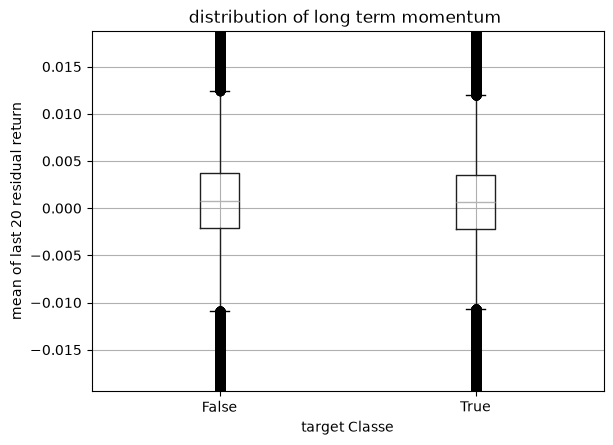

In [87]:
df_target_mean20.boxplot(
    column="RET_mean_20", 
    by="RET"
)
plt.xlabel(" target Classe ")
plt.ylabel("mean of last 20 residual return")
plt.title("distribution of long term momentum ")
plt.suptitle("")
#plt.ylim(0,0.4)
upper,lower=df_target_mean20["RET_mean_20"].quantile([0.01,0.99])
plt.ylim(upper,lower)



- we can see that the two boxes  false vs true look identical same median , same IQR , same wishker positions --> which is matching what the correlatiion and stat tables told us ... no meaningful difference in the dist between classes... 

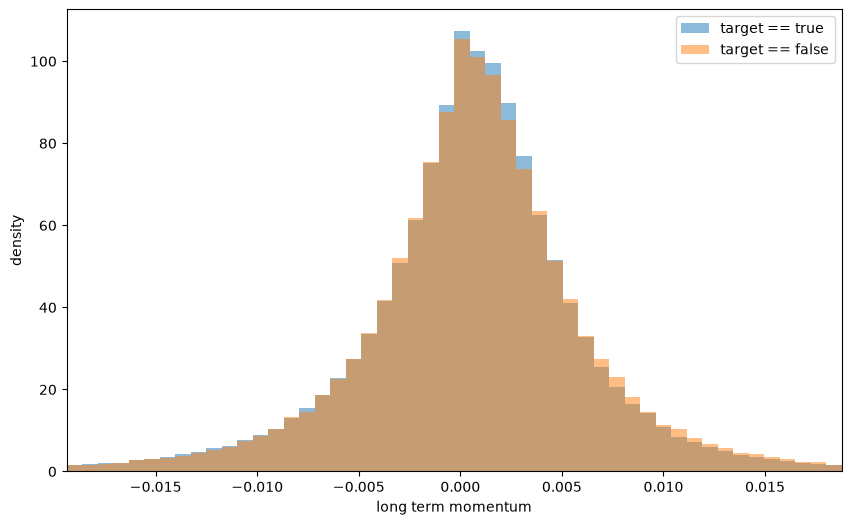

In [73]:
lower, upper =df_target_mean20["RET_mean_20"].quantile([0.01,0.99])
plt.figure(figsize=(10,6))
plt.hist(
    df_target_mean20[df_target_mean20["RET"]==True]["RET_mean_20"],
    bins=50,
    range=(lower,upper),
    alpha=0.5,
    label= "target == true",
    density=True
)
plt.hist(
    df_target_mean20[df_target_mean20["RET"]==False]["RET_mean_20"],
    bins=50,
    alpha=0.5,
    range=(lower,upper),
    label= "target == false",
    density=True
)
plt.xlabel("long term momentum")
plt.ylabel("density")

plt.xlim(lower,upper)
plt.legend()


- centred on 0 : for mean of daily return is alright on day to dat residual return should hover around 0 
- two classes overlap overall : same overall distribution over long term momentum... 
- momentum computed this way carries litlle to nosignal for this target  

# - short term momentum

In [93]:
df_target_mean5=pd.concat(
    [df_ret20_ret1["RET_mean_5"],Y_train["RET"]],
    axis=1
)
#df_target_mean20
corr_mean5_target= df_target_mean5["RET_mean_5"].corr(df_target_mean5["RET"])
float(corr_mean5_target)


-0.011343475229815967

In [94]:
stat_deltas=df_target_mean5.groupby(df_target_mean5["RET"])["RET_mean_5"].aggregate(["count","mean","median","std"])
stat_deltas.loc["delta"]=np.abs(stat_deltas.loc[True]- stat_deltas.loc[False])
stat_deltas

,count,mean,median,std
RET,,,,
False,209749.0,0.000984,0.000738,0.013387
True,208846.0,0.000682,0.000545,0.013275
delta,903.0,0.000302,0.000193,0.000113


(-0.03623091003471843, 0.039101389760997564)

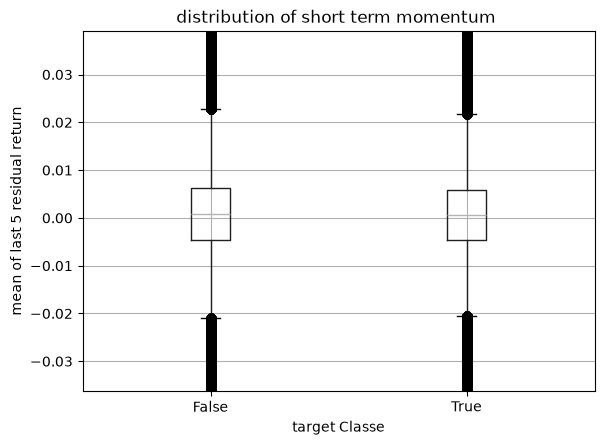

In [97]:
df_target_mean5.boxplot(
    column="RET_mean_5", 
    by="RET"
)
plt.xlabel(" target Classe ")
plt.ylabel("mean of last 5 residual return")
plt.title("distribution of short term momentum ")
plt.suptitle("")
#plt.ylim(0,0.4)
lower, upper =df_target_mean5["RET_mean_5"].quantile([0.01,0.99])
plt.ylim(lower,upper)



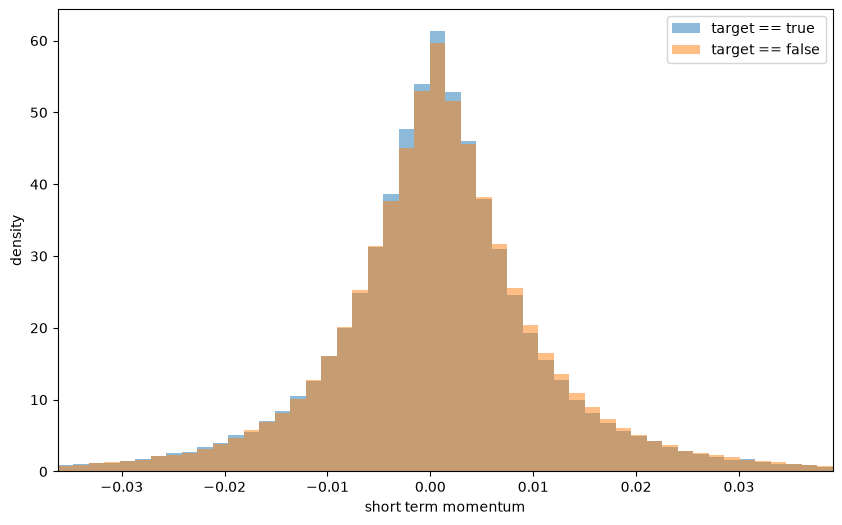

In [98]:
lower, upper =df_target_mean5["RET_mean_5"].quantile([0.01,0.99])
plt.figure(figsize=(10,6))
plt.hist(
    df_target_mean5[df_target_mean5["RET"]==True]["RET_mean_5"],
    bins=50,
    range=(lower,upper),
    alpha=0.5,
    label= "target == true",
    density=True
)
plt.hist(
    df_target_mean5[df_target_mean5["RET"]==False]["RET_mean_5"],
    bins=50,
    alpha=0.5,
    range=(lower,upper),
    label= "target == false",
    density=True
)
plt.xlabel("short term momentum")
plt.ylabel("density")

plt.xlim(lower,upper)
plt.legend()


## 3-Short term reversal : How unusual is yesterday specifically 

- based on an emperical finding large single day moves tend to reverse in the following days: driven by overreaction and short term liquidity effect
- a single feature is worth testing rather than folding into momentum aggregate 
- we gonna use  amore refined version RET_1 - the mean of the rest : to see how unusual was yesterday compared to the window we have

In [105]:
df_ret20_ret1["RET_REVERSAL"]=df_ret20_ret1["RET_1"] - df_ret20_ret1["RET_mean_20"]

df_reversal_target=pd.concat([df_ret20_ret1["RET_REVERSAL"],Y_train["RET"]],
                             axis=1,
                             )

corr_reversal_target=df_reversal_target["RET_REVERSAL"].corr(df_reversal_target["RET"])
float(corr_reversal_target)

-0.013442170125410113

- as expected hypothesis the correlation between the target and the short term revesal should be negative since the short terme reversal expecting the tomorrows residual to be corrected in the other trajectory as yesterday (i.e of yesterday's return is up tomorrows residueal tends to be down and viceversa )

- weak negative relationship between the target and reversal feature 
- /!\ we should observe that even the corr is week -0.0134 it's till now the strongest of all features tested 
- EVEN IF IT S NOT RELIABLE ENOUGH TO B A STRONG PREDICTOR 

In [107]:
stat_d=df_reversal_target.groupby(df_reversal_target["RET"])["RET_REVERSAL"].aggregate(["count","mean", "median", "std"])
stat_d.loc["delta"]=np.abs(stat_d.loc[True] - stat_d.loc[False])
stat_d

,count,mean,median,std
RET,,,,
False,209749.0,0.001179,0.000171,0.030759
True,208846.0,0.000327,-0.000162,0.032599
delta,903.0,0.000852,0.000333,0.001840


- we can again confirm what our reversal feature predict by seeing that the median between the true and the false ahs opposit signes 
- magnitude s still tiny 

(-0.07602594034902639, 0.0888219932774149)

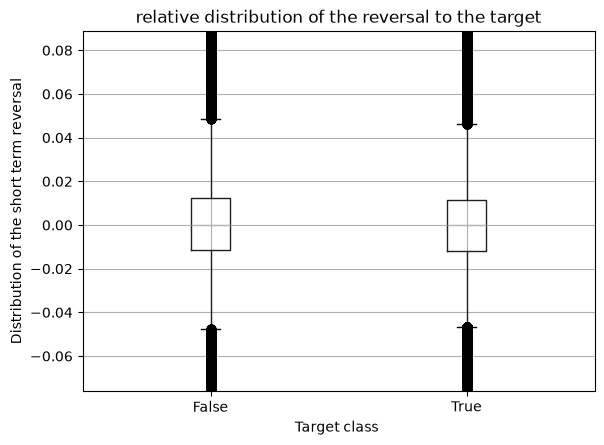

In [113]:
df_reversal_target.boxplot(
    column="RET_REVERSAL",
    by="RET",
)
plt.xlabel("Target class ")
plt.ylabel("Distribution of the short term reversal")
plt.title("relative distribution of the reversal to the target")
plt.suptitle("")

lower,upper=df_reversal_target["RET_REVERSAL"].quantile([0.01, 0.99])
plt.ylim(lower,upper)


Text(0, 0.5, 'Density')

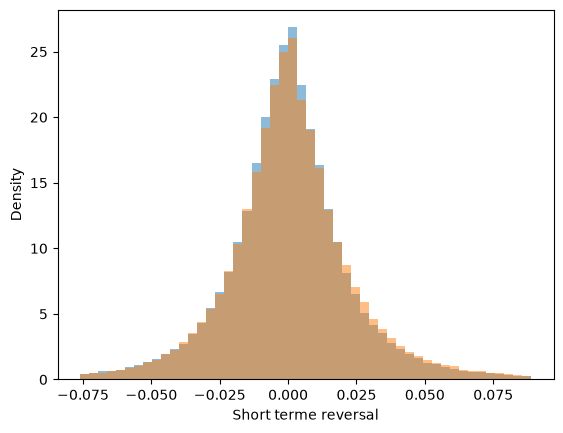

In [114]:

plt.hist(
    df_reversal_target[df_reversal_target["RET"]==True]["RET_REVERSAL"],
    bins=50,
    alpha=0.5,
    label="target==True",
    density=True,
    range=(lower,upper)
)

plt.hist(
    df_reversal_target[df_reversal_target["RET"]==False]["RET_REVERSAL"],
    bins=50,
    alpha=0.5,
    label="target==False",
    density=True,
    range=(lower,upper)
)
plt.xlabel("Short terme reversal")
plt.ylabel("Density")

- we can say that reversal show weakest but most consistent signal found : strongest correlation to the target (compared to others features tested), even if it's still week relationship but in a signal to noise problem this improvment can be exploitable 

## DRAFT *************************************************

Text(0.5, 1.0, 'Long term volatility of stocks')

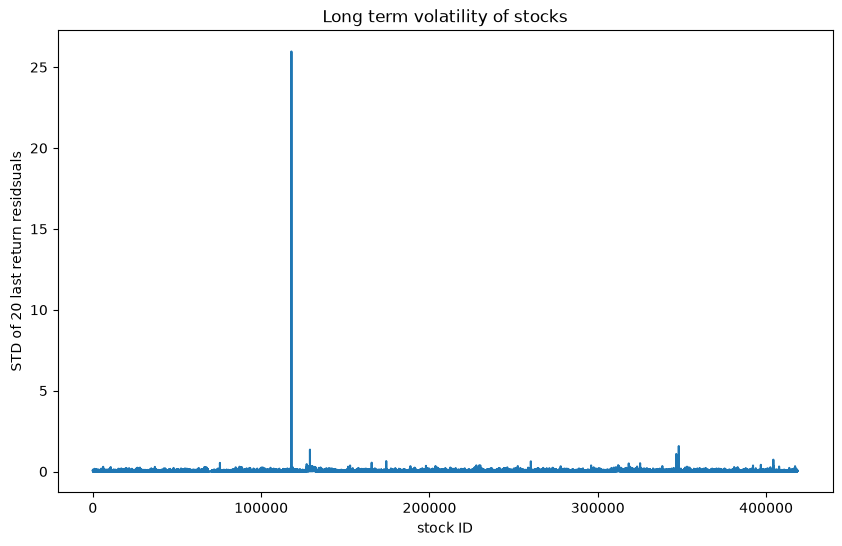

In [76]:

plt.figure(figsize=(10,6))

plt.plot(df_ret20_ret1.index,df_ret20_ret1["RET_STD_20"])
    
plt.xlabel("stock ID")
plt.ylabel("STD of 20 last return residsuals")
plt.title("Long term volatility of stocks")


- We can see that the long term volatility is a bit stable over stocks and variates around 0 , there's a peak at stock 117974 with a std=26 

In [77]:
long_term_vol_20=df_ret20_ret1["RET_STD_20"]
print(f"(id_max_vol,max_col) = {long_term_vol_20.idxmax(), int(long_term_vol_20.max())}")


(id_max_vol,max_col) = (117974, 25)


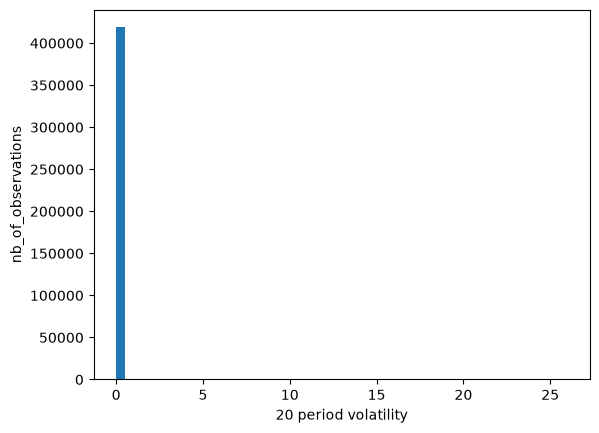

In [78]:
#let's take a look to the distribution of the of volatilty 
plt.hist(df_ret20_ret1["RET_STD_20"], bins=50)
plt.xlabel("20 period volatility")
plt.ylabel("nb_of_observations")
plt.show()
